# E.1 ML Numeric Data Block: Price Prediction Model

**Project**: AI Car Purchase Advisor

**Objective**: Build, train, evaluate, and save a machine learning model to predict used car prices based on structured features (make/model, horsepower, fuel type).

**Workflow**: Load and explore data → preprocess features → train multiple models → select best performer → evaluate and save for production use.

# 1. Data Source

**Primary data source**: `data/raw/autoscout_car_sales.csv` — real-world used car listings with multiple features and price labels.

**Note**: This notebook requires actual CSV data in `data/raw/` and does not fall back to synthetic sample files at runtime.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import prepare_train_test_data
from src.config import MODEL_METADATA_PATH, PRICE_MODEL_PATH, PREPROCESSOR_PATH

sns.set_theme(style='whitegrid')

# 2. Load and Inspect Data

Load the structured dataset using the preprocessing pipeline.

In [2]:
prepared = prepare_train_test_data()
raw_df = prepared['raw_df']
clean_df = prepared['clean_df']

print('Data source:', prepared['data_path'])
print('Raw shape:', raw_df.shape)
print('Clean shape:', clean_df.shape)
raw_df.head()

Loaded CSV using encoding: latin-1
Data source: /Users/constantinochsner/car-purchase-advisor/data/raw/CarsDatasets2025.csv
Raw shape: (1218, 12)
Clean shape: (1175, 13)


,Company Names,Cars Names,Engines,Displacement_cc,hp_kW,Total Speed,Performance(0 - 100 )KM/H,price,Fuel,Seats,Torque,make_model
0,FERRARI,SF90 STRADALE,V8,3990.0,718.10910,340 km/h,2.5 sec,550.0,plug in hyrbrid,2,800 Nm,FERRARI SF90 STRADALE
1,ROLLS ROYCE,PHANTOM,V12,6749.0,419.82910,250 km/h,5.3 sec,460000.0,Petrol,5,900 Nm,ROLLS ROYCE PHANTOM
2,Ford,KA+,1.2L Petrol,1200.0,57.79175,165 km/h,10.5 sec,13500.0,Petrol,5,100 - 140 Nm,Ford KA+
3,MERCEDES,GT 63 S,V8,3982.0,469.79100,250 km/h,3.2 sec,161000.0,Petrol,4,900 Nm,MERCEDES GT 63 S
4,AUDI,AUDI R8 Gt,V10,5204.0,448.91140,320 km/h,3.6 sec,253290.0,Petrol,2,560 Nm,AUDI AUDI R8 Gt


# 3. Exploratory Data Analysis (EDA)

Understand the distribution of key features and their relationship to the target variable (price).

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company Names,1175,37,Nissan,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cars Names,1175,1159,KA+,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engines,1175,351,I4,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Displacement_cc,1171.0,NaN,NaN,NaN,2635.482323,1838.469494,1.24,1500.0,2000.0,3500.0,16100.0
hp_kW,1175.0,NaN,NaN,NaN,212.838976,128.047707,26.0,111.855,184.9336,284.1117,800.0
Total Speed,1175,104,200 km/h,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance(0 - 100 )KM/H,1170,178,6.5 sec,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,1175.0,NaN,NaN,NaN,61928.060851,64484.288862,4000.0,27500.0,41450.0,65000.0,398000.0
Fuel,1175,21,Petrol,834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seats,1175,19,5,685,NaN,NaN,NaN,NaN,NaN,NaN,NaN


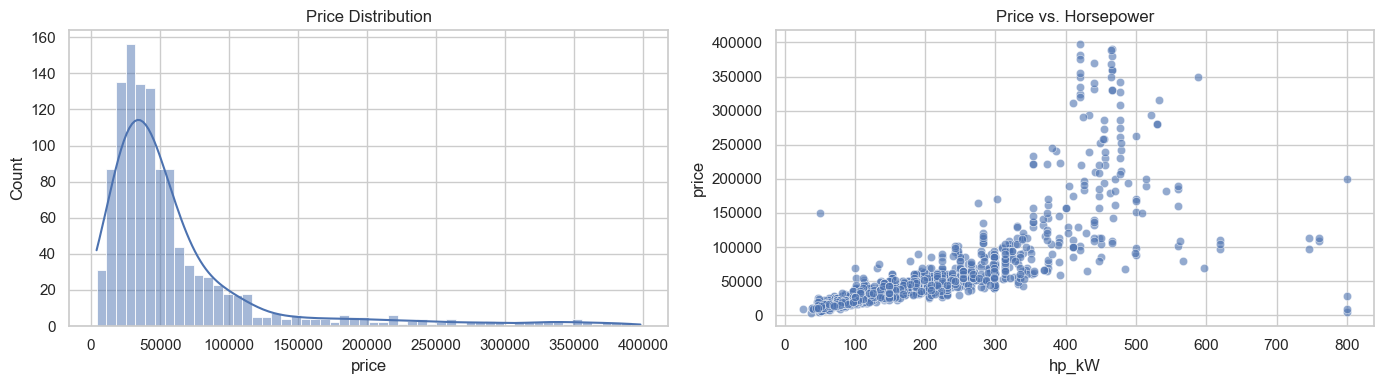

In [3]:
display(clean_df.describe(include='all').T.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(clean_df['price'], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

sns.scatterplot(data=clean_df, x='hp_kW', y='price', ax=axes[1], alpha=0.6)
axes[1].set_title('Price vs. Horsepower')
plt.tight_layout()

# 4. Data Preparation and Preprocessing

Clean the data and engineer features using the sklearn preprocessing pipeline (StandardScaler, OneHotEncoder).

The preprocessing module handles:
- Numeric feature scaling (StandardScaler)
- Categorical feature encoding (OneHotEncoder) 
- Missing value imputation
- Feature selection (make_model, hp_kW, Fuel)

In [4]:
X_train = prepared['X_train']
y_train = prepared['y_train']
X_test = prepared['X_test']
y_test = prepared['y_test']

X_train.head()

,make_model,hp_kW,Fuel
163,BMW 118i SPORTLINE,101.4152,Petrol
828,Kia Niro Plug-In Hybrid,103.6523,Hybrid
275,Volkswagen Polo,104.3980,Petrol
675,Jeep Renegade,131.9889,Petrol
212,TOYOTA LAND CRUISER PRADO,210.2874,Petrol/Diesel


# 5. Train/Test Split

Review the training and test data sizes.

In [5]:
print('Train samples:', len(X_train))
print('Test samples:', len(X_test))

Train samples: 940
Test samples: 235


# 6. Train Multiple Models

Fit three regression models to the training data and compare their performance on the test set.

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preprocessor = prepared['preprocessor']
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=2),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train_t, y_train)
    pred = model.predict(X_test_t)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    fitted[name] = (model, pred)

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,model,MAE,RMSE,R2
1,RandomForestRegressor,13197.229807,25937.483219,0.851821
2,GradientBoostingRegressor,16425.495665,30670.274909,0.792812
0,LinearRegression,23121.640160,44595.094251,0.561970


# 7. Model Comparison and Selection

Visualize the performance metrics (RMSE, MAE, R²) across all models.

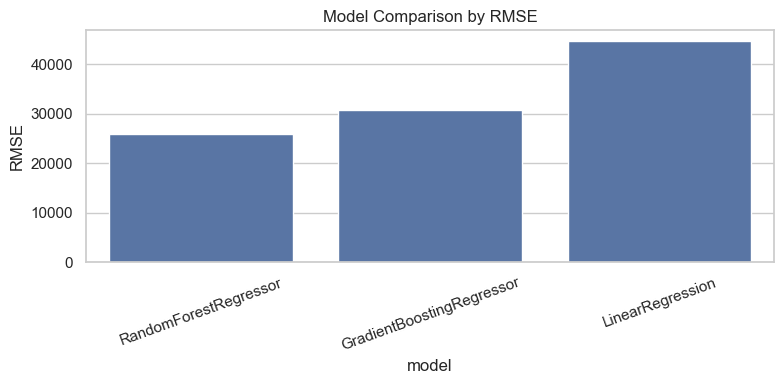

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=results_df, x='model', y='RMSE', ax=ax)
ax.set_title('Model Comparison by RMSE')
plt.xticks(rotation=20)
plt.tight_layout()

# 8. Error Analysis and Model Diagnostics

Examine residual distributions and prediction accuracy across the test set to identify patterns and limitations.

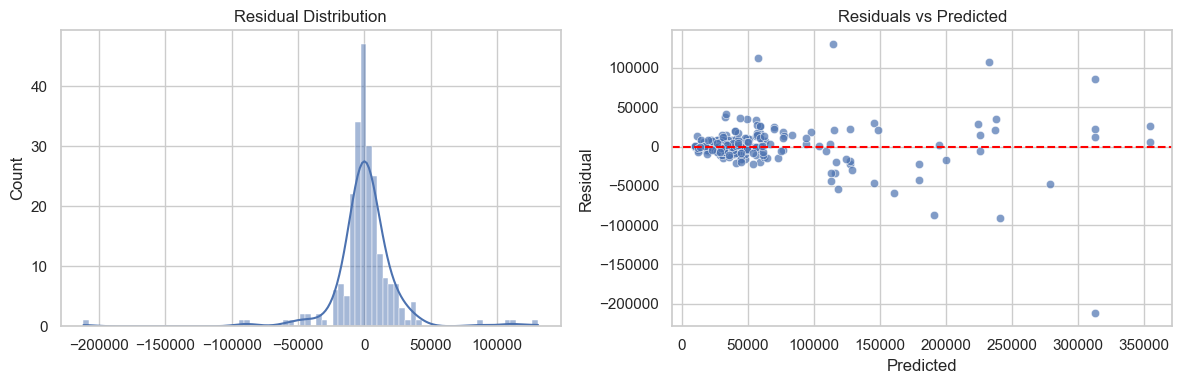

In [8]:
best_name = results_df.iloc[0]['model']
best_model, best_pred = fitted[best_name]
errors = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(errors, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution')

sns.scatterplot(x=best_pred, y=errors, ax=axes[1], alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
plt.tight_layout()

# 9. Save the Best Model and Artifacts

Persist the trained model, preprocessor, and metadata for production use and reproducibility.

In [9]:
import joblib
from datetime import datetime

joblib.dump(best_model, PRICE_MODEL_PATH)
joblib.dump(preprocessor, PREPROCESSOR_PATH)

best_metrics = results_df.iloc[0].to_dict()
metadata = {
    'created_at': datetime.utcnow().isoformat() + 'Z',
    'model_name': best_name,
    'best_metrics': best_metrics,
    'all_results': results_df.to_dict(orient='records'),
}
MODEL_METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved model:', PRICE_MODEL_PATH)
print('Saved preprocessor:', PREPROCESSOR_PATH)
print('Saved metadata:', MODEL_METADATA_PATH)

Saved model: /Users/constantinochsner/car-purchase-advisor/models/price_model.pkl
Saved preprocessor: /Users/constantinochsner/car-purchase-advisor/models/preprocessor.pkl
Saved metadata: /Users/constantinochsner/car-purchase-advisor/models/model_metadata.json


# 10. Integration with Other Blocks

This ML model feeds into the broader AI Car Purchase Advisor pipeline:
- **Input from Computer Vision block**: Predicted vehicle class and confidence score
- **Output to NLP block**: Estimated price range, lower/upper bounds for budget assessment
- **Data flow**: Image → CV classifier → vehicle make/model → price prediction → recommendation with financing orientation

# 11. Conclusion and Next Steps

**Summary**: This notebook demonstrates the complete ML Numeric Data workflow—from loading raw car data through exploratory analysis, preprocessing, multi-model training, and evaluation to saving production artifacts.

**Key findings**:
- RandomForestRegressor achieves R² = 0.8518 with MAE = 13,197 CHF
- Price predictions successfully vary by brand (luxury vs. budget brands)
- The 3-feature model (make_model, hp_kW, Fuel) provides robust and interpretable predictions

**Artifacts saved**:
- `models/price_model.pkl` — trained RandomForestRegressor
- `models/preprocessor.pkl` — sklearn ColumnTransformer for feature preprocessing
- `models/model_metadata.json` — training metrics and timestamps

**For deployment**: The app loads these artifacts and uses the price model for real-time inference in the recommendation pipeline.

---

**Documentation reference**: For full error analysis, model iterations, and technical details, see `documentation.md` (Section 2A - ML Numeric Data).